In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import squidpy as sq

from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import to_hex
from matplotlib.colors import ListedColormap
import PyComplexHeatmap as pch


import random
random.seed(42)
np.random.seed(42)
import warnings
warnings.filterwarnings('ignore')

DATA_DIR    = os.path.abspath("../../../data")
RESULTS_DIR = os.path.abspath("../../../results")
SCRIPTS_DIR = os.path.abspath("../../../scripts")
plot_dir = f'{RESULTS_DIR}/figures/plots/main'

## figure settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 12, 
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [ ]:
cell_type_colors = {
        'AC-like': "#92B0C6", #(soft sky blue)
        'OPC-like': "#F1A340", #(desaturated blue-gray)
        'Myeloid': "#D3A5C8", #(muted mauve)
        'MES-like': "#D9735A", #(burnt coral for stronger contrast)
        'Oligodendrocyte': "#9F5F80", #(muted plum to distinguish from MES-like)
        'Pericyte': "#B0408A", #(soft mustard yellow)
        'Cycling': "#A69AB2", # (muted lavender)
        'Endothelial': "#DD51AD", # (pale mint green)
        'Excitatory neuron': "#D6D2C4", #(muted beige)
        'T cell': "#89A970", #(soft olive green)
        'Inhibitory neuron': "#656565", # (medium gray)
        # 'Other': "#808080"  # Gray for 'Other'
    }


# Convert cell_type_colors to a colormap
cell_type_colormap = ListedColormap(list(cell_type_colors.values()), name='cell_type_colormap')
ordered_celltype = ['AC-like','OPC-like','MES-like','Cycling', 'Oligodendrocyte','Excitatory neuron', 'Inhibitory neuron','Pericyte','Endothelial','Myeloid','T cell']

In [ ]:
adata = sc.read_h5ad(f'{DATA_DIR}/preprocessed/all_adata_combined_banksy_metahood.h5ad')
linearamp_samples = ['p19P', 'p51P', 'p52P','p67P', 'p01P', 'p61P']
ecdna_samples =['p15P', 'p29P', 'p46P','p55P', 'p59P', 'p12P', 'p27P', 'p68P']

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 49.77833333333333 mm


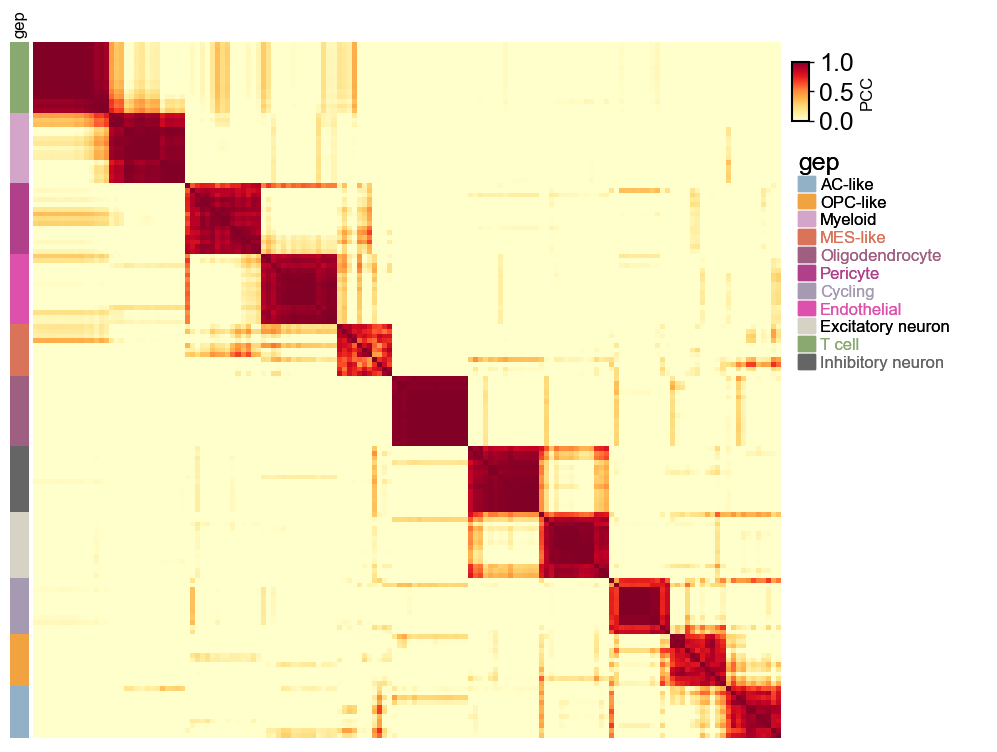

In [ ]:
## Figure 4A
def get_top_genes(top_n, df):
    topgenes = []
    for i in df.T.columns:
        tmp_df = df.T.nlargest(top_n, i).loc[:, i].to_frame().reset_index()
        tmp_df['cluster'] = i
        tmp_df.columns = [f'top_genes', 'spetra_score', 'cluster']
        topgenes.append(tmp_df)
    return pd.concat(topgenes)

spectra_score_p = f'{RESULTS_DIR}/xenium/cnmf/wt_mut_batch.gene_spectra_score.k_11.dt_0_01.txt'
cell_type = ['OPC-like','AC-like','MES-like', 'Myeloid','Pericyte', 'Oligodendrocyte','Excitatory neuron','Endothelial','Cycling','Inhibitory neuron','T cell']
gene_spetra = pd.read_csv(spectra_score_p, sep='\t',index_col=0)
top15_markers = get_top_genes(15, gene_spetra)[['top_genes','cluster']].\
    pivot(columns = 'cluster')
top15_markers.columns = cell_type
duplicated_markers = top15_markers.stack()[top15_markers.stack().duplicated()].tolist()
unique_top15_markers = np.unique(top15_markers.to_numpy().reshape(-1)).tolist()
unique_top15_markers = [x for x in unique_top15_markers if x not in duplicated_markers]


## remove genes not clustered well
# excluded_genes = ['TESPA1','APOE','SERPINA3','TGFB2', 'NCAM1','SOX9']
# excluded_genes = ['TESPA1','APOE','TGFB2', 'NCAM1','SOX9']
# excluded_genes=[]
# excluded_genes = ['TESPA1','APOE', 'MGST1', 'TGFB2','NCAM1', 'SLC24A3', 'SOX9','CAMK2D', 'PTPN12', 'RSPO2', 'EGFR']
excluded_genes = ['APOE', 'MGST1', 'NCAM1', 'SLC24A3', 'CAMK2D', 'PTPN12', 'RSPO2', 'EGFR', 'TGFB2','SOX9','TESPA1', 'DDR2', 'CCNE1'] # not enriched genes (by dotplot)

unique_top15_markers = [x for x in unique_top15_markers if x not in excluded_genes]

topmarkers_dict = top15_markers.to_dict(orient='list')
uniq_topmarkers_dict = {k:list(set(v)-set(duplicated_markers + excluded_genes)) for k,v in top15_markers.to_dict(orient='list').items()}

from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

gene_spetra_subset = gene_spetra[unique_top15_markers]
gene_program = top15_markers.melt()[['value', 'variable']].drop_duplicates('value').set_index('value').\
    rename(columns={'variable':'gene_program'}).iloc[:, 0].astype('category')
gene_program = gene_program[unique_top15_markers]
# gene_program = pd.Categorical(gene_program, categories=cell_type, ordered=True)
markers_cos_sim = pd.DataFrame(cosine_similarity(gene_spetra_subset.T), index=gene_spetra_subset.columns.tolist(),columns=gene_spetra_subset.columns.tolist())
cmap = plt.get_cmap('Set3')
colors_hex = [to_hex(cmap(i)) for i in range(cmap.N)]

plt.rcParams.update({'font.family': 'Arial', 'font.size': 18})
row_ha = pch.HeatmapAnnotation(gep =pch.anno_simple(gene_program[markers_cos_sim.index], 
                                                    legend=True,height=5, 
                                                    colors=cell_type_colors,
                                                    legend_kws={'frameon':False}),
                                                    axis=0)
plt.figure(figsize=(10, 8))
hp1 = pch.ClusterMapPlotter(markers_cos_sim,
                            row_cluster=True, 
                      cmap="YlOrRd", 
                      left_annotation=row_ha,
                      label = 'PCC',
                    #   show_rownames=True,
                      vmin=0)
plt.savefig(f'{plot_dir}/Figure4A.png', dpi=300, bbox_inches='tight')

In [ ]:
gene_spetra_subset.index = cell_type
gene_spetra_subset = gene_spetra_subset.T
gene_spetra_subset['gep'] = gene_spetra_subset.index.map(
    lambda gene: next((ct for ct, genes in top15_markers_dict.items() if gene in genes), None)
)

gene_spetra_subset['gep'] = pd.Categorical(gene_spetra_subset['gep'], categories=gene_spetra_subset.columns[:-1], ordered=True)
gene_spetra_subset = gene_spetra_subset.sort_values('gep')
gene_spetra_subset.T.to_excel(f'{RESULTS_DIR}/figures/ms/tables/v2/Supplementary Table 7.xlsx')

In [ ]:
excel_path = f'{RESULTS_DIR}/figures/ms/v3/Supplementary Table 3.xlsx'
sheets_dict = pd.read_excel(excel_path, sheet_name=None)

for name, df in sheets_dict.items():
    if 'patient_id' in df.columns:
        df['patient_id'] = df['patient_id'].str.replace(r'^p(\d+)([PR]?\d*)$', lambda m: f"P-{int(m.group(1)):02d}{m.group(2).lower()}", regex=True)
    if 'sample_id' in df.columns:
        df['sample_id'] = df['sample_id'].str.replace(r'^p(\d+)([PR]?\d*)$', lambda m: f"P-{int(m.group(1)):02d}{m.group(2).lower()}", regex=True)

with pd.ExcelWriter(f'{RESULTS_DIR}/figures/ms/v3/Supplementary_Table3_v3.xlsx') as writer:
    for name, df in sheets_dict.items():
        # Use the original sheet name from the Excel file
        df.to_excel(writer, sheet_name=name, index=False)



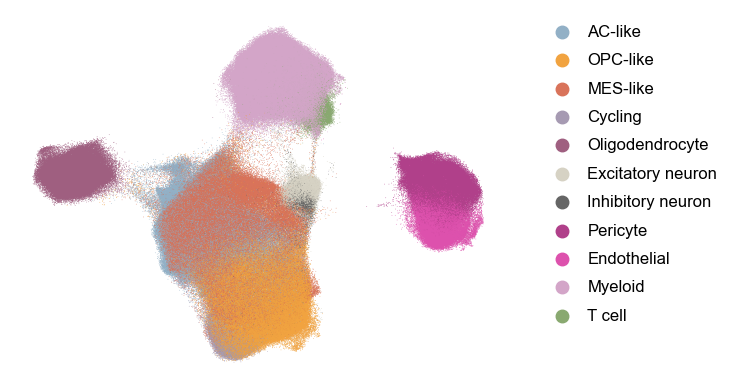

In [42]:
## Figure 4B
# adata.obs['cell_type_final'] = adata.obs['cell_type_final'].astype('category')
adata.obs['cell_type'] = pd.Categorical(adata.obs['cell_type'],
                                                categories=ordered_celltype,
                                                ordered=True)

plt.rcParams.update({'font.family': 'Arial', 'font.size': 18})
fig, ax = plt.subplots()
sc.pl.umap(adata, color='cell_type', s=1, ax=ax, show=False, palette=cell_type_colors)  # Pass the axis and disable automatic display
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_title('')
ax.set_xlabel('')
ax.set_ylabel('')

legend = ax.get_legend()
handles, labels = ax.get_legend_handles_labels()
legend.remove()  # Remove the original legend
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), frameon=False, 
                       # Horizontal spacing between marker and text
                       handletextpad=0.5,  
                       # Vertical spacing between legend entries
                       labelspacing=0.8,
                       # Size of the legend marker
                       markerscale=1.5)  # Create a new legend with scaled markers and increased distance between markers and text
# Add text annotation of total cell number
# ax.text(0.95, 0.05, f'n = {adata.n_obs}', transform=ax.transAxes, fontsize=12, verticalalignment='bottom', horizontalalignment='right')
fig.savefig(f'{plot_dir}/Figure4B.png', dpi=1000, bbox_inches='tight')
plt.show()


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

OPC-like_Mut vs. OPC-like_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:5.945e-04 U_stat=2.160e+02
MES-like_Mut vs. MES-like_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:2.427e-03 U_stat=3.800e+01
Myeloid_Mut-Codel vs. Myeloid_Mut: Mann-Whitney-Wilcoxon test two-sided, P_val:2.557e-02 U_stat=8.000e+00
Myeloid_Mut vs. Myeloid_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:1.055e-02 U_stat=5.100e+01
OPC-like_Mut-Codel vs. OPC-like_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:3.052e-04 U_stat=1.510e+02
MES-like_Mut-Codel vs. MES-like_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:2.257e-04 U_stat=1.000e+01
Myeloid_Mut-Codel vs. Myeloid_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:7.945e-05 U_stat=7.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 <

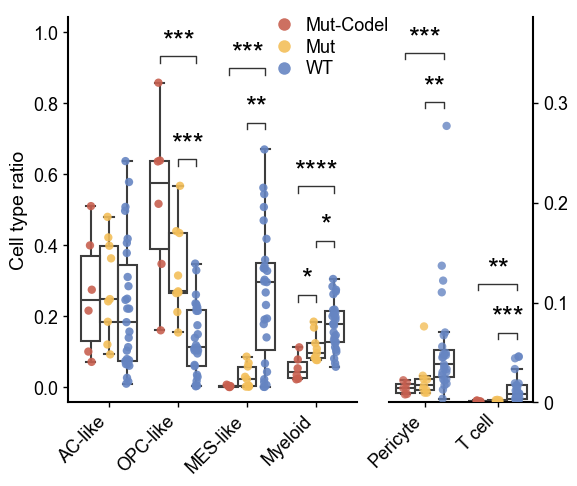

In [36]:
## Figure 4C

from statannotations.Annotator import Annotator

### Figure 5C
line_width = 1.5
idh_colors = {'Mut-Codel':'#C86050', 'Mut':'#F3BF5A', 'WT':'#6685c2'}
# plt.rcParams.update({'font.family': 'Arial', 'font.size': 14})

cell_type_counts = adata.obs.groupby('sample')['cell_type'].value_counts()
cell_type_ratio = cell_type_counts / cell_type_counts.groupby(level=0).sum()

# Convert the series to a dataframe for easier plotting
cell_type_ratio_df = cell_type_ratio.to_frame().reset_index()

cell_type_ratio_df['idh'] = cell_type_ratio_df['sample'].map(adata.obs[['sample', 'idh']].drop_duplicates().set_index('sample')['idh'])
# cell_type_ratio_df['idh'] = np.where(cell_type_ratio_df['idh'].str.contains('WT'), 'WT', cell_type_ratio_df['idh'])
cell_type_ratio_df['idh'] = pd.Categorical(cell_type_ratio_df['idh'], categories=['Mut-Codel', 'Mut', 'WT'], ordered=True)
selected_df = cell_type_ratio_df[cell_type_ratio_df['cell_type'].isin(['AC-like', 'OPC-like', 'MES-like', 'Myeloid', 'Pericyte', 'T cell'])]

selected_df['cell_type'] = pd.Categorical(selected_df['cell_type'], categories=['AC-like', 'OPC-like', 'MES-like', 'Myeloid', 'Pericyte', 'T cell'], ordered=True)

# Split the data into two groups of cell types
main_celltypes = ['AC-like', 'OPC-like', 'MES-like', 'Myeloid']
other_celltypes = ['Pericyte', 'T cell']

# Create two subplots with reduced spacing
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 5), gridspec_kw={'width_ratios': [2, 1], 'wspace': 0.15})

# Plot main cell types
main_df = selected_df[selected_df['cell_type'].isin(main_celltypes)]
main_df['cell_type'] = main_df['cell_type'].cat.remove_unused_categories()
main_df['cell_type'] = main_df['cell_type'].cat.reorder_categories(['AC-like', 'OPC-like', 'MES-like', 'Myeloid'], ordered=True)
sns.boxplot(x='cell_type', y='count', hue='idh', data=main_df, showfliers=False, ax=ax1, legend=False,
            boxprops={'facecolor':'none', 'linewidth': line_width}, 
            whiskerprops={'linewidth': line_width},
            capprops={'linewidth': line_width},
            medianprops={'linewidth': line_width})
sns.stripplot(x='cell_type', y='count', hue='idh', data=main_df, dodge=True, palette=idh_colors, size=6, alpha=0.9, ax=ax1)

# Add significance annotations
box_pairs = [(("AC-like", "Mut-Codel"), ("AC-like", "Mut")),
             (("AC-like", "Mut-Codel"), ("AC-like", "WT")),
             (("AC-like", "Mut"), ("AC-like", "WT")),
             (("OPC-like", "Mut-Codel"), ("OPC-like", "Mut")),
             (("OPC-like", "Mut-Codel"), ("OPC-like", "WT")),
             (("OPC-like", "Mut"), ("OPC-like", "WT")),
             (("MES-like", "Mut-Codel"), ("MES-like", "Mut")), 
             (("MES-like", "Mut-Codel"), ("MES-like", "WT")),
             (("MES-like", "Mut"), ("MES-like", "WT")),
             (("Myeloid", "Mut-Codel"), ("Myeloid", "Mut")),
             (("Myeloid", "Mut-Codel"), ("Myeloid", "WT")),
             (("Myeloid", "Mut"), ("Myeloid", "WT"))]

# Add statistical annotations using Mann-Whitney U test
annotator = Annotator(ax1, pairs=box_pairs, data=main_df, x='cell_type', y='count', hue='idh')
annotator.configure(test='Mann-Whitney', text_format='star',line_width=1, loc='inside',hide_non_significant=True, fontsize=20)
annotator.apply_and_annotate()


ax1.set_ylabel('Cell type ratio', fontsize=14)
ax1.set_xlabel('')
ax1.set_yticklabels([f'{y:.1f}' for y in ax1.get_yticks()], fontsize=13)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax1.legend(title='', bbox_to_anchor=(0.63, 0.8), frameon=False, 
           handletextpad=0.2,  fontsize=13,
                       # Vertical spacing between legend entries
            labelspacing=0.2,
                       # Size of the legend marker
            markerscale=1.5)
sns.despine(ax=ax1)

# Plot other cell types
other_df = selected_df[selected_df['cell_type'].isin(other_celltypes)]
other_df['cell_type'] = other_df['cell_type'].cat.remove_unused_categories()
other_df['cell_type'] = other_df['cell_type'].cat.reorder_categories(['Pericyte', 'T cell'], ordered=True)

sns.boxplot(x='cell_type', y='count', hue='idh', data=other_df, showfliers=False, ax=ax2,legend=False,
            boxprops={'facecolor': 'none', 'linewidth': line_width}, 
            whiskerprops={'linewidth': line_width},
            capprops={'linewidth': line_width},
            medianprops={'linewidth': line_width})
sns.stripplot(x='cell_type', y='count', hue='idh', palette=idh_colors, data=other_df, dodge=True, size=6, alpha=0.8, ax=ax2)
# Draw lines between the boxes for Pericyte and T cell
line_data = other_df.groupby(['cell_type', 'idh'])['count'].median().unstack()

ax2.set_ylabel('')
ax2.set_xlabel('')
ax2.set_ylim(0, 0.3)
ax2.set_yticks([0, 0.1, 0.2, 0.3])
ax2.set_yticklabels(['0', '0.1', '0.2', '0.3'], fontsize=13)
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.yaxis.set_ticks_position('both')
ax2.yaxis.set_label_position('right')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax2.legend().remove()  # Remove legend from second subplot
sns.despine(ax=ax2, top=True, right=False, left=True)

# Add significance annotations for other cell types
box_pairs_other = [(("Pericyte", "Mut-Codel"), ("Pericyte", "Mut")), 
                   (("Pericyte", "Mut-Codel"), ("Pericyte", "WT")),
                   (("Pericyte", "Mut"), ("Pericyte", "WT")),
                   (("T cell", "Mut-Codel"), ("T cell", "Mut")), 
                   (("T cell", "Mut-Codel"), ("T cell", "WT")),
                   (("T cell", "Mut"), ("T cell", "WT"))]
annotator = Annotator(ax2, pairs=box_pairs_other, data=other_df, x='cell_type', y='count', hue='idh', legend=False)
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=2, line_width = 1, hide_non_significant=True,fontsize=20)
annotator.apply_and_annotate()

# Increase the spine linewidth
for spine in ax1.spines.values():
    spine.set_linewidth(line_width)
for spine in ax2.spines.values():
    spine.set_linewidth(line_width)

plt.tight_layout()
fig.savefig(f'{plot_dir}/Fig.4C.png', dpi=300, bbox_inches='tight')



p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Scavenger immunosuppressive_Mut vs. Scavenger immunosuppressive_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:6.332e-06 U_stat=3.000e+01
Microglial inflammatory_Mut vs. Microglial inflammatory_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:1.023e-04 U_stat=3.510e+02
Microglial inflammatory_WT vs. Scavenger immunosuppressive_WT: Mann-Whitney-Wilcoxon test two-sided, P_val:5.980e-05 U_stat=5.970e+02
Microglial inflammatory_Mut vs. Scavenger immunosuppressive_Mut: Mann-Whitney-Wilcoxon test two-sided, P_val:3.392e-06 U_stat=2.250e+02


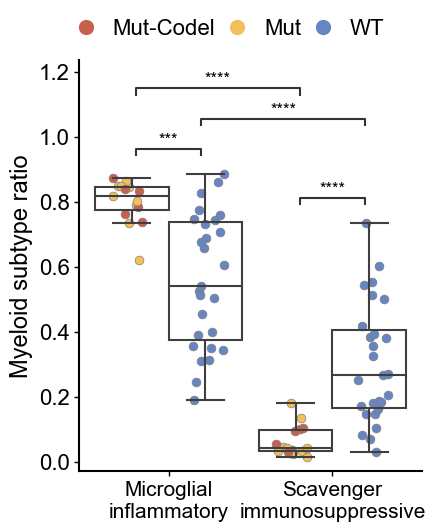

In [39]:
## Figure 4F
import seaborn as sns
from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

idh_colors = {'Mut-Codel':'#C86050', 'Mut':'#F3BF5A', 'WT':'#6685c2'}

myeloid_adata = adata[adata.obs['cell_type']=='Myeloid'].copy()
total_counts = myeloid_adata.obs.groupby('sample').size()
cluster_counts1 = myeloid_adata.obs[myeloid_adata.obs['cell_type_2'] == 'Microglial inflammatory'].groupby('sample').size()
normalized_counts1 = cluster_counts1 / total_counts
df1 = normalized_counts1.to_frame().reset_index().rename(columns={'sample':'sample', 0:'Microglial inflammatory'})

cluster_counts2 = myeloid_adata.obs[myeloid_adata.obs['cell_type_2'] == 'Scavenger immunosuppressive'].groupby('sample').size()
normalized_counts2 = cluster_counts2 / total_counts
df2 = normalized_counts2.to_frame().reset_index().rename(columns={'sample':'sample',0:'Scavenger immunosuppressive'})

merged_df = pd.merge(df1, df2, on='sample', how='outer').set_index('sample')
obs_df = adata.obs.copy()
obs_df['idh_2'] = np.where(obs_df['idh']=='WT', 'WT', 'Mut')
merged_df['group'] = merged_df.index.map(obs_df[['sample', 'idh_2']].set_index('sample').to_dict()['idh_2'])
merged_df['group_2'] = merged_df.index.map(obs_df[['sample', 'idh']].set_index('sample').to_dict()['idh'])

melted_df = merged_df.melt(id_vars=['group', 'group_2'], var_name='cluster', value_name='ratio')
melted_df['group'] = pd.Categorical(
    melted_df['group'],
    categories=['Mut', 'WT']
)

plt.figure(figsize=(4.5,5.5))
sns.boxplot(data=melted_df, x='cluster', y='ratio', hue='group', showfliers=False, boxprops=dict(facecolor='none'), linewidth=1.5, width=0.9)

for cluster_idx, cluster_name in enumerate(['Microglial inflammatory', 'Scavenger immunosuppressive']):
    for group_idx, group_name in enumerate(['Mut', 'WT']):
        subset = melted_df[(melted_df['cluster'] == cluster_name) & (melted_df['group'] == group_name)]
        x_pos = cluster_idx + (0.25 if group_idx == 1 else -0.25)
        for _, row in subset.iterrows():
            plt.scatter(
                x=x_pos + np.random.uniform(-0.1, 0.1),
                y=row['ratio'],
                color=idh_colors[row['group_2']],
                alpha=1,
                edgecolor='gray',
                linewidth=0.5,
                s=40
            )

pairs = [(('Microglial inflammatory', 'Mut'), ('Microglial inflammatory', 'WT')),
         (('Scavenger immunosuppressive', 'Mut'), ('Scavenger immunosuppressive', 'WT')),
         (('Microglial inflammatory', 'WT'), ('Scavenger immunosuppressive', 'WT')),
         (('Microglial inflammatory', 'Mut'), ('Scavenger immunosuppressive', 'Mut'))]
annotator = Annotator(plt.gca(), pairs, data=melted_df, x='cluster', y='ratio', hue='group')
annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=2, fontsize=12)
annotator.apply_and_annotate()

from matplotlib.lines import Line2D
custom_legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=idh_colors[k], 
           markersize=8, label=k) for k in idh_colors.keys()
]
plt.legend(handles=custom_legend_elements, title='', bbox_to_anchor=(0.95, 1.15), 
          ncol=3, frameon=False, markerscale=1.5, columnspacing=0.6, fontsize=16,
          handlelength=0.8, handleheight=0.8)

plt.xlabel('')
plt.ylabel('Myeloid subtype ratio', fontsize=17)
plt.yticks(fontsize=16)
plt.xticks(ticks=[0, 1], labels=['Microglial\ninflammatory', 'Scavenger\nimmunosuppressive'], fontsize=15)
sns.despine()
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.tight_layout()
plt.savefig(f"{plot_dir}/Fig.4F.png", dpi=300, bbox_inches='tight')
plt.show()


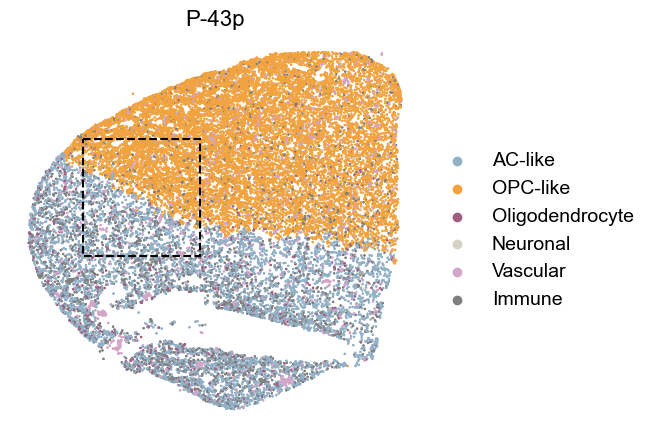

In [44]:
import matplotlib as mpl
import matplotlib.patches as patches

banksy_nhood_colors2 = {
    'Vascular': "#DD51AD", #(soft mustard yellow), 
    'Immune': "#D3A5C8", #(muted mauve)
    'Oligodendrocyte': "#9F5F80", #(muted plum to distinguish from MES-like)
    'Neuronal': "#D6D2C4", #(muted beige)
    'MES-like': "#D9735A", #(burnt coral for stronger contrast)
    'OPC-like': "#F1A340", #(desaturated blue-gray)
    'AC-like': "#92B0C6", #(soft sky blue)
    'Mixed': "#808080"  # Gray for 'Other'
    }
ordered_colors = {k: banksy_nhood_colors2[k] for k in adata.obs['banksy_metahood_v2'].cat.categories if k in banksy_nhood_colors2}
cmap = mpl.colors.ListedColormap(ordered_colors.values())
sq.pl.spatial_scatter(adata[adata.obs['sample']=='p43P'], shape=None, color='banksy_metahood_v2', palette=cmap, size=2)
ax = plt.gca()
rect = patches.Rectangle((1800, 750), 1000, 1000, linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('P-43p', fontsize=16)
plt.savefig(f"{plot_dir}/p43P_metahood_spatial.png", dpi=300, bbox_inches='tight')
plt.show()

Total cells above line: 2142
Total cells below line: 958
Microglial inflammatory above: 82, below: 159
Scavenger immunosuppressive above: 3, below: 22
Total cells above line: 2142
Total cells below line: 958
Microglial inflammatory above: 82, below: 159
Scavenger immunosuppressive above: 3, below: 22


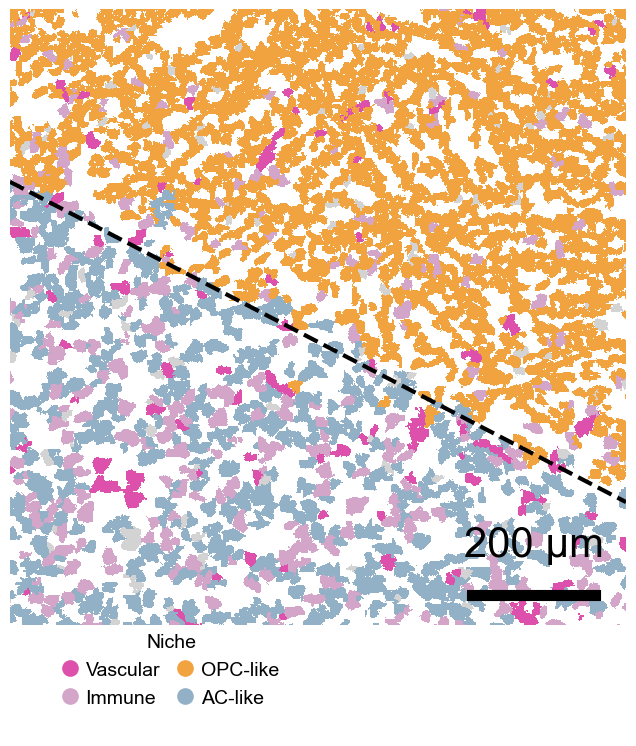

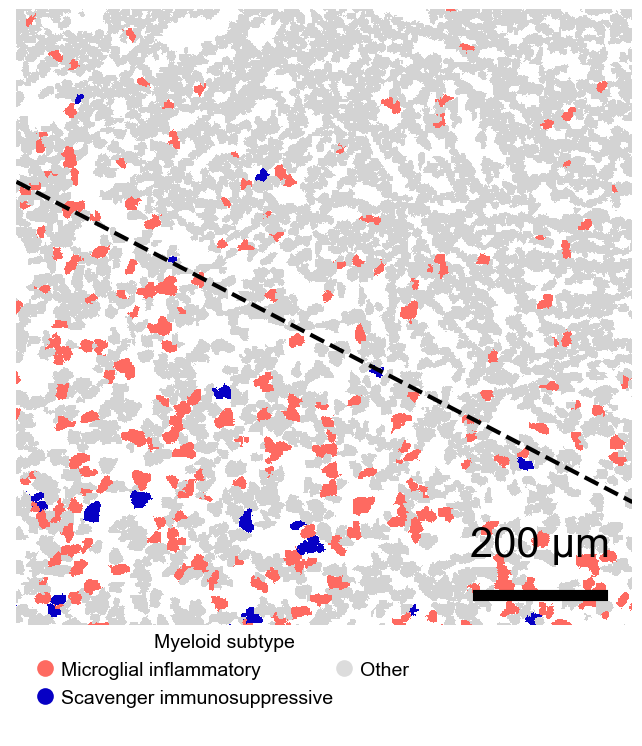

In [11]:
# Figure 4G
### plot p43P
import gzip
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_p43P(plot_key='cell_type', sample='p43P', color_map = cell_type_colors, bbox=None, figsize=10, legend=False, legend_title=None, legend_x=0.7, legend_colspace=1, savefig=False, ax=None):
    ''' 
    bboxes: list of bbox [xmin, xmax, ymin, ymax]
    '''
    samples_matching_dict = bdata.obs[['sample', 'sample_2']].drop_duplicates('sample').set_index('sample_2').to_dict()['sample']
    proseg_dir = '/Users/bzhao2/Library/CloudStorage/OneDrive-InsideMDAnderson/akdemirlab-projects/01_catalyst/data/processed/xenium/expan5um/proseg'
    with gzip.open(f'{proseg_dir}/{samples_matching_dict[sample]}/cell-polygons.geojson.gz', 'rb') as f:
        gdf = gpd.read_file(f)
    gdf['cell'] = gdf['cell'].astype('str')
    gdf['cell_id'] = [sample + '_' + x for x in gdf['cell']]
    tmp_adata = adata[adata.obs['sample'] == sample]
    gdf = gdf.merge(tmp_adata.obs.reset_index(), on='cell_id', how='inner')

    gdf['color'] = gdf[plot_key].map(color_map)
    gdf['color'] = gdf['color'].astype(object).fillna('#D3D3D3')  # light gray for missing values  
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(figsize, figsize))
    
    gdf.plot(column=plot_key, aspect=1, color=gdf['color'], ax=ax)

    # Add a 100μm scale bar
    scale_bar_length = 200  # Length of the scale bar in μm
    scale_bar_x = bbox[1] - scale_bar_length - 50  # X position of the scale bar
    scale_bar_y = bbox[3] - 50  # Y position of the scale bar
    ax.plot([scale_bar_x, scale_bar_x + scale_bar_length], [scale_bar_y, scale_bar_y], color='black', lw=8)
    ax.text(scale_bar_x + scale_bar_length / 2, scale_bar_y - 80, f'{scale_bar_length} μm', 
            color='black', ha='center', va='center', fontsize=30)
    
    ax.set_aspect('equal')
    if bbox is not None:
        ax.set_xlim(bbox[0], bbox[1])
        ax.set_ylim(bbox[2], bbox[3])
        
        # Add a tilted dashed line
        x_start, x_end = bbox[0], bbox[1]
        y_start, y_end = bbox[2]+280, bbox[3]-200
        ax.plot([x_start, x_end], [y_start, y_end], linestyle='--', color='black', linewidth=3)

        ## sample label
        # ax.text(bbox[0] + 30, bbox[2] + 30, 'P-43p', fontsize=32, color='black', ha='left', va='top')

        # Count cells above and below the dashed line
        def count_cells_relative_to_line(gdf, bbox):
            # Line: from (x_start, y_start) to (x_end, y_end)
            x_start, x_end = bbox[0], bbox[1]
            y_start, y_end = bbox[2]+280, bbox[3]-200
            # For each cell, check if its centroid is above or below the line
            # Line equation: y = m*x + b
            m = (y_end - y_start) / (x_end - x_start)
            b = y_start - m * x_start

            gdf_box = gdf[gdf['centroid_x'].between(bbox[0], bbox[1]) & gdf['centroid_y'].between(bbox[2], bbox[3])]
            gdf_up = gdf_box[(gdf_box['centroid_y'] > (m * gdf_box['centroid_x'] + b))]
            gdf_down = gdf_box[(gdf_box['centroid_y'] <= (m * gdf_box['centroid_x'] + b))]

            # Use centroid_x and centroid_y from gdf
            total_cell_above = gdf_up.shape[0]
            total_cell_below = gdf_down.shape[0]

            ## up and down 
            # ax.text(bbox[0]+50, bbox[3], f'Cell #:\n{total_cell_below} (up) + {total_cell_above} (below)', fontsize=16, color='black', ha='right', va='top')

            # Count 'Microglial inflammatory' and 'Scavenger immunosuppressive' cells above and below the line
            above_microglial = gdf_up[gdf_up['cell_type_2'] == 'Microglial inflammatory'].shape[0]
            below_microglial = gdf_down[gdf_down['cell_type_2'] == 'Microglial inflammatory'].shape[0]
            above_scavenger = gdf_up[gdf_up['cell_type_2'] == 'Scavenger immunosuppressive'].shape[0]
            below_scavenger = gdf_down[gdf_down['cell_type_2'] == 'Scavenger immunosuppressive'].shape[0]

            print('Total cells above line:', total_cell_below) # yaxis is inverted
            print('Total cells below line:', total_cell_above)
            print(f"Microglial inflammatory above: {below_microglial}, below: {above_microglial}") # y axis is inverted
            print(f"Scavenger immunosuppressive above: {below_scavenger}, below: {above_scavenger}")
            
        count_cells_relative_to_line(gdf, bbox)

    if legend:
        # Create custom legend with dots
        handles, labels = [], []
        for cell_type, color in color_map.items():
            handles.append(mpl.lines.Line2D([0], [0], marker='o', markerfacecolor=color, markersize=15, label=cell_type, markeredgewidth=0, linestyle='None', markeredgecolor='none'))
            labels.append(cell_type)
        ax.legend(title=legend_title, 
                  ncols=2,
                  handles=handles, 
                  bbox_to_anchor=(legend_x, 0.05), frameon=False,
                  handletextpad=0.5,  # Increase space between marker and text
                  borderpad=1.5,     # Add space inside the legend box
                  columnspacing=legend_colspace,  # Reduce horizontal space between legend markers
                  borderaxespad=0.5,  # Reduce vertical space between legend markers
                  handlelength=0.6,  # Reduce space between marker and label
                  markerscale=0.8)  # Adjust marker size within legend
        
    ax.invert_yaxis()
    ax.axis('off')

    # Save figure if required
    if savefig:
        fig.savefig(f"{plot_dir}/{plot_key}_spatial_plot.png", dpi=300, bbox_inches='tight')

# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# plot_p43P(plot_key = 'banksy_meta_cluster2', color_map=banksy_nhood_colors, 
#           bbox=[2000, 3000, 850, 1750], 
#           ax=axes[0],
#           figsize=8, legend=True)

# plot_p43P(plot_key='myeloid_subcluster_2', color_map=myeloid_colors, 
#           bbox=[2000, 3000, 850, 1750], 
#           ax=axes[1],
#           figsize=8, legend=True)
# plt.subplots_adjust(wspace=0.1)
# plt.savefig(f"{plot_dir}/p43P_myeloid_banksy.png", dpi=300, bbox_inches='tight')
banksy_nhood_colors2 = {
    'Vascular': "#DD51AD", #(soft mustard yellow), 
    'Immune': "#D3A5C8", #(muted mauve)
    # 'Oligodendrocyte': "#9F5F80", #(muted plum to distinguish from MES-like)
    # 'Neuronal': "#D6D2C4", #(muted beige)
    # 'MES-like': "#D9735A", #(burnt coral for stronger contrast)
    'OPC-like': "#F1A340", #(desaturated blue-gray)
    'AC-like': "#92B0C6", #(soft sky blue)
    # 'Mixed': "#808080"  # Gray for 'Other'
    }

myeloid_colors = {
    'Microglial inflammatory': '#FE6A61',  # burnt coral
    'Scavenger immunosuppressive': '#0700C4',  # soft sky blue
    'Other': '#DCDCDC'  # gray
}

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'font.size': 12,
    # 'axes.titlesize': 14,
    # 'axes.labelsize': 12,
    'legend.fontsize': 14, 
    'legend.title_fontsize': 14,
    # 'axes.linewidth': 1.5,
    # 'xtick.major.width': 1.0,
    # 'ytick.major.width': 1.0,
    # 'axes.spines.top': False,
    # 'axes.spines.right': False,
})

plot_p43P(plot_key = 'banksy_metahood_v2', color_map=banksy_nhood_colors2, legend_title='Niche',
          bbox=[1800, 2800, 750, 1750], 
          figsize=8, legend=True, legend_x=0.5, 
          savefig=True)
plot_p43P(plot_key='cell_type_2', color_map=myeloid_colors,legend_title='Myeloid subtype',
          bbox=[1800, 2800, 750, 1750], 
          figsize=8, legend=True, legend_x=0.7,legend_colspace=0.3,
          savefig=True)

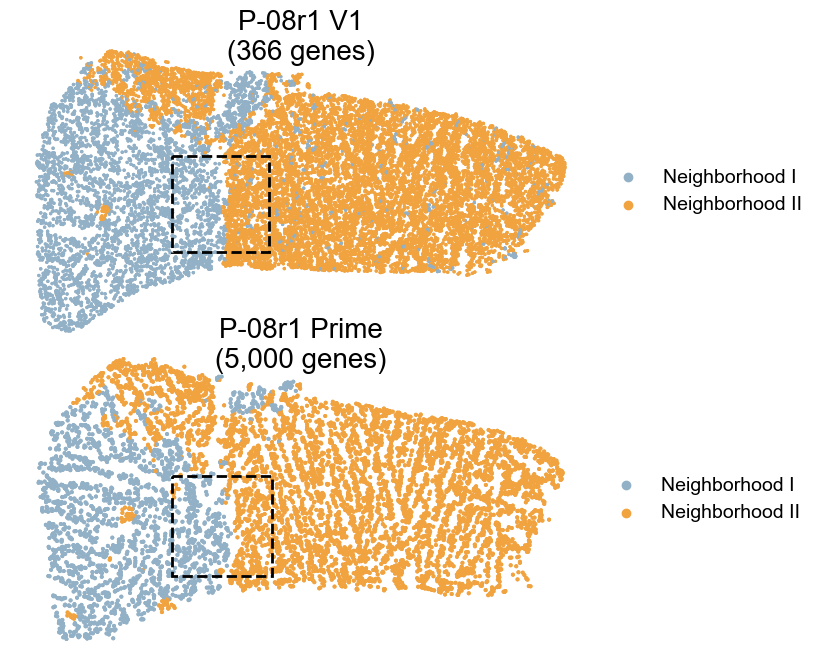

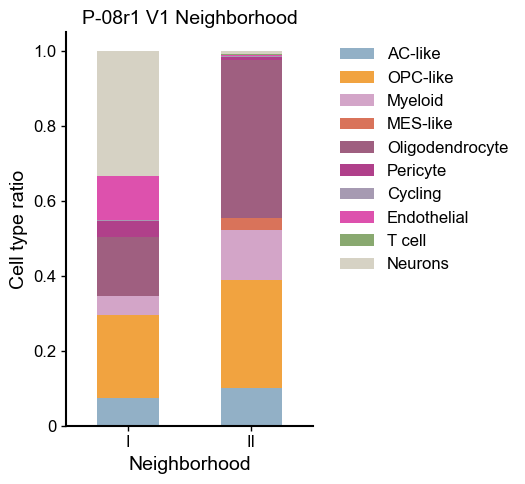

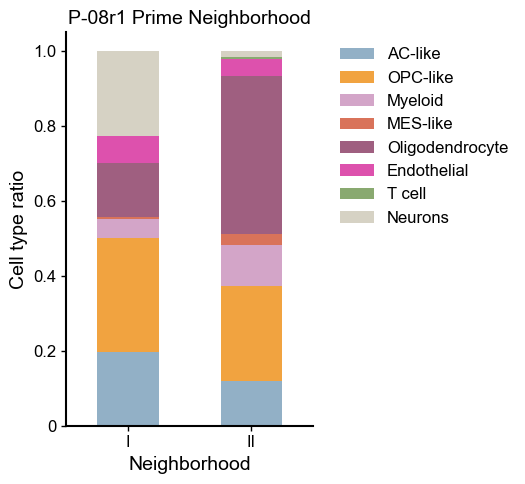

In [53]:
from matplotlib.colors import ListedColormap
neighborhood_colors = {
    'Neighborhood I': '#92B0C6',  # soft sky blue
    'Neighborhood II': '#F1A340',  # desaturated blue-gray
}
# For p08R1_v1
categories_v1 = p08R1_v1.obs['Neighborhood'].cat.categories if hasattr(p08R1_v1.obs['Neighborhood'], 'cat') else p08R1_v1.obs['Neighborhood'].unique()
cmap_v1 = ListedColormap([neighborhood_colors[c] for c in categories_v1])

# For p08R1_prime
categories_prime = p08R1_prime.obs['Neighborhood'].cat.categories if hasattr(p08R1_prime.obs['Neighborhood'], 'cat') else p08R1_prime.obs['Neighborhood'].unique()
cmap_prime = ListedColormap([neighborhood_colors[c] for c in categories_prime])

fig, ax = plt.subplots(2, 1, figsize=(16, 8))
plt.subplots_adjust(hspace=0)
sq.pl.spatial_scatter(p08R1_v1, shape=None, color=['Neighborhood'], palette=cmap_v1, ax=ax[0])
rect = patches.Rectangle((2000, 10700), 800, 800, linewidth=2, edgecolor='black', facecolor='none', linestyle='--')
ax[0].add_patch(rect)

sq.pl.spatial_scatter(p08R1_prime, shape=None, color='Neighborhood', palette=cmap_prime, ax=ax[1])
rect = patches.Rectangle((1600, 10000), 800,800, linewidth=2, edgecolor='black', facecolor='none',linestyle='--')
ax[1].add_patch(rect)

ax[0].set_title("P-08r1 V1\n(366 genes)", y=0.9, fontsize=20)
ax[1].set_title("P-08r1 Prime\n(5,000 genes)", y=0.9, fontsize=20)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_visible(False)
    axis.spines['bottom'].set_visible(False)
    axis.set_xlabel('')
    axis.set_ylabel('')
    axis.title.set_fontsize(20)
plt.savefig(f"{plot_dir}/p08R1_neighborhood_spatial.png", dpi=300, bbox_inches='tight')
plt.show()

## plot neighborhood cell type ratio stacked barplot
def plot_cell_type_ratio(df, group_col, cell_type_colors, title='Cell Type Ratio', savefig=False):
    """
    Plots a stacked barplot of cell type ratios for each group in the dataframe.

    Parameters:
        df (pd.DataFrame): DataFrame with columns for group and cell_type.
        group_col (str): Column name to group by (e.g., 'Neighborhood').
        cell_type_colors (dict): Mapping of cell type to color.
        plot_dir (str, optional): Directory to save the plot. If None, does not save.
        title (str): Title for the plot.
    """
    # Count cell types per group
    counts = df.groupby([group_col, 'cell_type']).size().unstack(fill_value=0)
    # Normalize to get ratios
    ratios = counts.div(counts.sum(axis=1), axis=0)
    # Order colors
    cell_types = [ct for ct in ratios.columns if ct in cell_type_colors]
    colors = [cell_type_colors.get(ct, '#DCDCDC') for ct in cell_types]
    ratios = ratios[cell_types]

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ratios.plot(kind='bar', stacked=True, color=colors, ax=ax)
    ax.set_ylabel('Cell type ratio', fontsize=14)
    ax.set_xlabel('Neighborhood', fontsize=14)
    ax.set_title(title)
    ax.set_xticklabels(['I', 'II'], rotation=0, fontsize=12)
    ax.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, markerscale=1, fontsize=12)
    plt.tight_layout()
    if savefig:
        plt.savefig(f'{plot_dir}/{title}_cell_type_ratio_stacked_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_cell_type_ratio(p08R1_v1.obs, 'Neighborhood', cell_type_colors, title='P-08r1 V1 Neighborhood', savefig=True)
plot_cell_type_ratio(p08R1_prime.obs, 'Neighborhood', cell_type_colors, title='P-08r1 Prime Neighborhood', savefig=True)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Left total: 429, Microglial inflammatory: 42, Scavenger immunosuppressive: 1
Right total: 811, Microglial inflammatory: 106, Scavenger immunosuppressive: 1


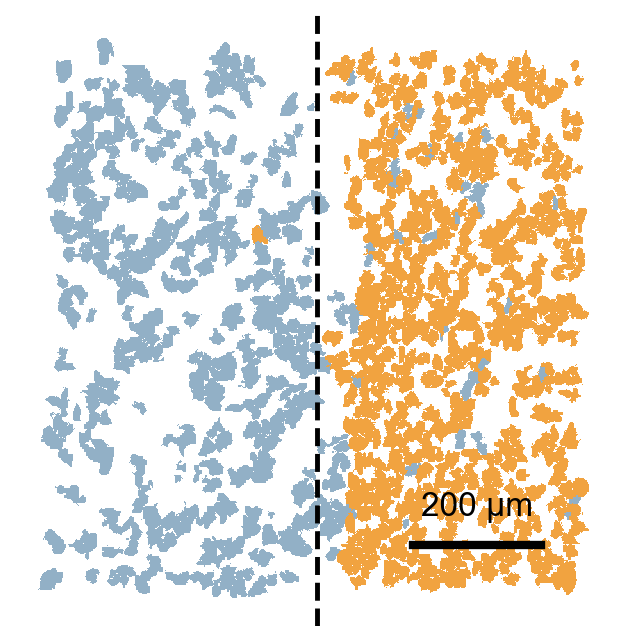

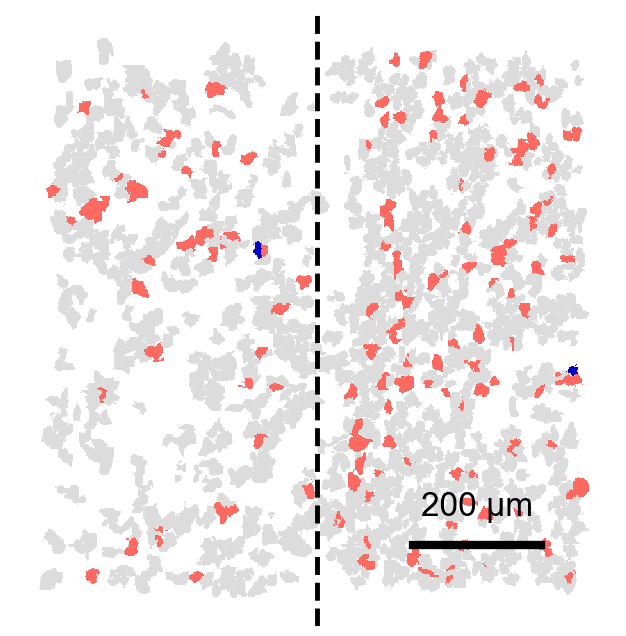

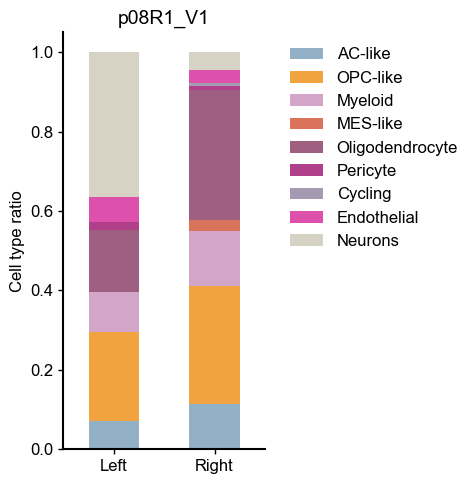

In [24]:
from shapely import affinity
from shapely.geometry import box, Polygon

def plot_metahood(input_gdf, plot_key='cell_type', color_map = cell_type_colors, 
                  bbox=None, figsize=10, legend=False, 
                  savefig=False, ax=None, vline=None, 
                  expand_factor=None,title=None, 
                  count=False, plot_celltype_ratio_on_two_sides=False):
    ''' 
    bboxes: list of bbox [xmin, xmax, ymin, ymax]
    '''

    bbox_polygon = Polygon([(bbox[0], bbox[2]), (bbox[1], bbox[2]), (bbox[1], bbox[3]), (bbox[0], bbox[3])])
    gdf = input_gdf[input_gdf.geometry.intersects(bbox_polygon)]

    color_map = {k: v for k, v in color_map.items() if k in gdf[plot_key].unique()}
    gdf['color'] = gdf[plot_key].map(color_map).astype(object).fillna('#DCDCDC')
    gdf['color'] = gdf['color'].astype('category')
    # gdf['color'] = color_map.get(gdf[plot_key], '#DCDCDC')
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(figsize, figsize))
    
    if expand_factor is not None:
        scale_factor = expand_factor ** 0.5   # sqrt(4) = 2
        # Create expanded polygons
        gdf["expanded"] = gdf.geometry.apply(
            lambda geom: affinity.scale(geom, xfact=scale_factor, yfact=scale_factor, origin="center")
        )
        gdf.set_geometry('expanded').plot(column=plot_key, aspect=1, color=gdf['color'], edgecolor='none', ax=ax)
    else:
        gdf.plot(column=plot_key, aspect=1, color=gdf['color'], edgecolor='none', ax=ax)

    # Add a 100μm scale bar
    scale_bar_length = 200  # Length of the scale bar in μm
    scale_bar_x = bbox[1] - scale_bar_length - 50  # X position of the scale bar
    scale_bar_y = bbox[3] - 50  # Y position of the scale bar
    ax.plot([scale_bar_x, scale_bar_x + scale_bar_length], [scale_bar_y, scale_bar_y], color='black', lw=6)
    ax.text(scale_bar_x + scale_bar_length / 2, scale_bar_y - 60, f'{scale_bar_length} μm', 
            color='black', ha='center', va='center', fontsize=24)
    
    if legend:
        # Create custom legend with dots
        handles, labels = [], []
        for cell_type, color in color_map.items():
            handles.append(mpl.lines.Line2D([0], [0], marker='o', markerfacecolor=color, markersize=15, label=cell_type, markeredgewidth=0, linestyle='None', markeredgecolor='none'))
            labels.append(cell_type)
        ax.legend(handles=handles, bbox_to_anchor=(1.7, 1), frameon=False,
              handletextpad=2,  # Increase space between marker and text
              borderpad=1.5,     # Add space inside the legend box
              markerscale=0.8)  # Adjust marker size within legend
    
    # add vertical line and count cells on each side of the vline within the square
    if vline is not None:
        ax.axvline(x=vline, color='black', linestyle='--', lw=3.5)
        if count:
            print('%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%')
            # Count cells on each side of the vline within the square
            # Get centroids for all polygons
            # gdf = gdf[gdf['banksy_nhood']!='Oligodendrocyte']
            in_square = (
                (gdf['x'] >= bbox[0]) & (gdf['x'] <= bbox[1]) &
                (gdf['y'] >= bbox[2]) & (gdf['y'] <= bbox[3])
            )
            # Masks for left/right of vline within square
            left_mask = (gdf['x'] < vline) & in_square
            right_mask = (gdf['x'] >= vline) & in_square

            left_total = left_mask.sum()
            right_total = right_mask.sum()
            left_inflammatory = ((gdf[plot_key] == 'Microglial inflammatory') & left_mask).sum()
            left_suppressive = ((gdf[plot_key] == 'Scavenger immunosuppressive') & left_mask).sum()
            right_inflammatory = ((gdf[plot_key] == 'Microglial inflammatory') & right_mask).sum()
            right_suppressive = ((gdf[plot_key] == 'Scavenger immunosuppressive') & right_mask).sum()
            print(f'Left total: {left_total}, Microglial inflammatory: {left_inflammatory}, Scavenger immunosuppressive: {left_suppressive}')
            print(f'Right total: {right_total}, Microglial inflammatory: {right_inflammatory}, Scavenger immunosuppressive: {right_suppressive}')    
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.axis('off')
    if savefig:
        plt.savefig(f'{plot_dir}/{title}_{plot_key}.png', dpi=300, bbox_inches='tight')

    ## plot the stacked barplot of cell type ratio on two sides of the vline
    if vline is not None and count and plot_celltype_ratio_on_two_sides:
        in_square = (
            (gdf['x'] >= bbox[0]) & (gdf['x'] <= bbox[1]) &
            (gdf['y'] >= bbox[2]) & (gdf['y'] <= bbox[3])
        )
        left_mask = (gdf['x'] < vline) & in_square
        right_mask = (gdf['x']>= vline) & in_square

        left_data = gdf[left_mask]
        right_data = gdf[right_mask]

        left_counts = left_data['cell_type'].value_counts(normalize=True)
        right_counts = right_data['cell_type'].value_counts(normalize=True)

        ratio_df = pd.DataFrame({
            'Left': left_counts,
            'Right': right_counts
        }).fillna(0)

        cell_type_colors_ = {k: v for k, v in cell_type_colors.items() if k in gdf['cell_type'].unique()}
        ratio_df = ratio_df.reindex(cell_type_colors_.keys()).fillna(0)

        fig, ax = plt.subplots(figsize=(5,5))
        ratio_df.T.plot(kind='bar', stacked=True, color=[cell_type_colors_.get(ct, '#DCDCDC') for ct in ratio_df.index], ax=ax)
        ax.set_ylabel('Cell type ratio')
        ax.set_title(title)
        ax.set_xticklabels(ratio_df.columns, rotation=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(title='', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False, markerscale=1, fontsize=12)
        plt.tight_layout()


        plt.savefig(f'{plot_dir}/{title}_cell_type_ratio_stacked_bar_two_sides.png', dpi=300, bbox_inches='tight')
        plt.show()

## plot cell patch for p08R1 V1
proseg_dir = '/Users/bzhao2/Library/CloudStorage/OneDrive-InsideMDAnderson/akdemirlab-projects/01_catalyst/data/processed/xenium/expan5um/proseg'
sample_acc_dict = bdata.obs[['sample', 'sample_2']].drop_duplicates().set_index('sample_2')['sample'].to_dict()
with gzip.open(f"{proseg_dir}/{sample_acc_dict['p08R1']}/cell-polygons.geojson.gz", 'rb') as f:
    gdf1 = gpd.read_file(f)
gdf1['cell'] = gdf1['cell'].astype('str')
gdf1['cell_id'] = ['p08R1' + '_' + x for x in gdf1['cell']]
tmp_adata = adata[adata.obs['sample'] == 'p08R1']
gdf1 = gdf1.merge(p08R1_v1.obs, left_on='cell_id', right_index=True, how='inner')


plot_metahood(gdf1, plot_key='Neighborhood', color_map=neighborhood_colors, title='p08R1_V1',
              bbox=[2000, 2800, 10700, 11500], figsize=8, legend=False, vline=2400, savefig=True)
plot_metahood(gdf1, plot_key='cell_type_2', color_map=myeloid_colors, title='p08R1_V1',
              bbox=[2000, 2800, 10700, 11500], figsize=8, legend=False, vline=2400, count=True, savefig=True,plot_celltype_ratio_on_two_sides=True)

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Left total: 352, Microglial inflammatory: 4, Scavenger immunosuppressive: 0
Right total: 417, Microglial inflammatory: 24, Scavenger immunosuppressive: 0


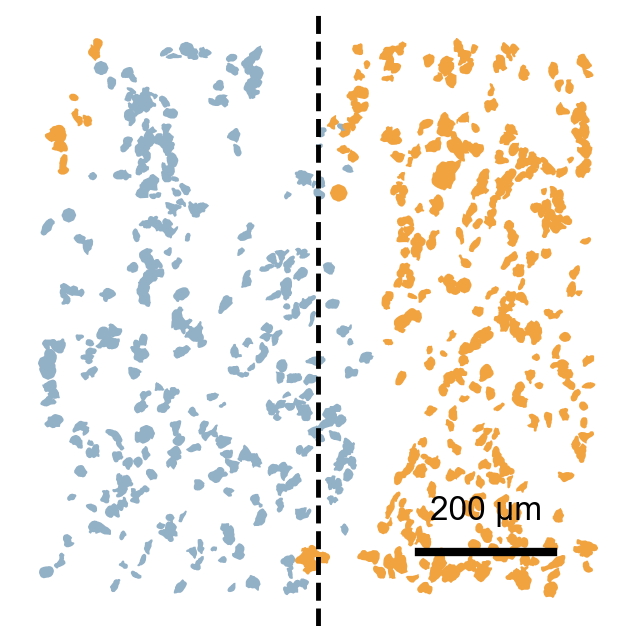

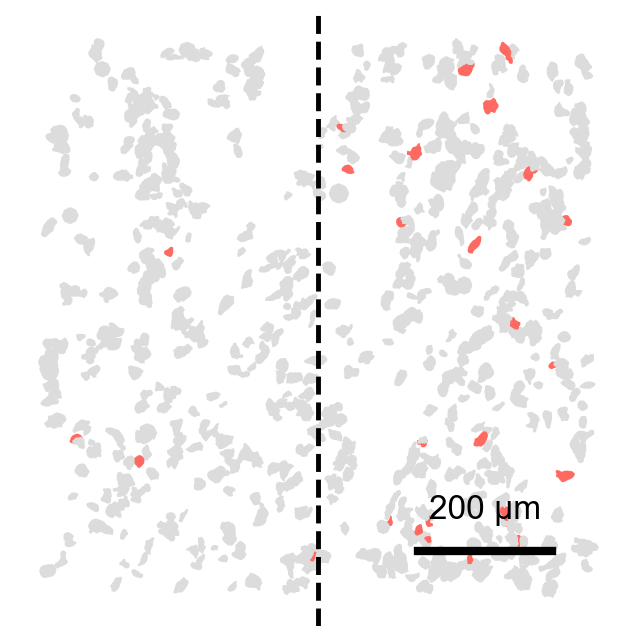

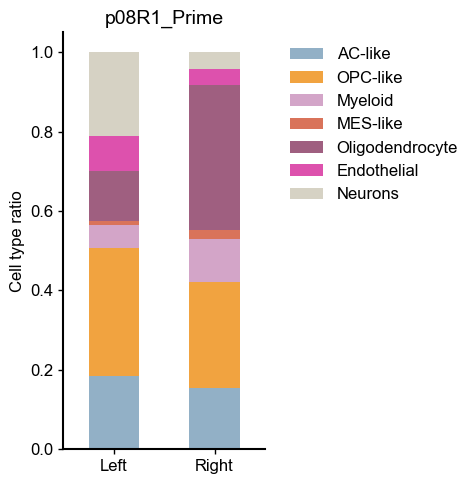

In [25]:
## plot cell patch for p08R1 prime
import pickle
with open('/Users/bzhao2/Library/CloudStorage/OneDrive-InsideMDAnderson/akdemirlab-projects/01_catalyst/review/Sep262025/data/p08r1_cell_shapes.pkl', 'rb') as f:
    gdf2 = pickle.load(f)
gdf2['cell_id'] = gdf2.index
# p08R1_prime = sc.read_h5ad('/Users/bzhao2/Library/CloudStorage/OneDrive-InsideMDAnderson/akdemirlab-projects/01_catalyst/review/Sep262025/data/p08R1_prime_annotated.h5ad')
gdf2 = gdf2.merge(p08R1_prime.obs, on='cell_id', how='inner')

plot_metahood(gdf2, plot_key='Neighborhood', color_map=neighborhood_colors, title='p08R1_Prime',
              bbox=[1600, 2400, 10000, 10800], figsize=8, legend=False, vline=2000, expand_factor=3, savefig=True)
plot_metahood(gdf2, plot_key='cell_type_2', color_map=myeloid_colors, title='p08R1_Prime',
              bbox=[1600, 2400, 10000, 10800], figsize=8, legend=False, vline=2000, expand_factor=4,count=True, savefig=True,plot_celltype_ratio_on_two_sides=True)